# ClosetAI · Analisi di Machine Learning

> **Corso**: Design per l'innovazione sostenibile — Università di Pisa
> **Progetto**: ClosetAI · Pre-esame

Questo notebook accompagna il prototipo **ClosetAI** e copre i tre
compiti classici di Machine Learning richiesti dal corso:

1. **Classificazione** — prevedere se un capo diventerà "fantasma"
   (mai indossato dopo X giorni).
2. **Regressione** — stimare quante volte un capo verrà indossato
   nei prossimi 90 giorni.
3. **Clustering** — raggruppare i capi del guardaroba in "stili"
   senza etichette.

I dati sono **sintetici** ma realistici: la funzione
`generate_wardrobe()` produce un guardaroba di 200 capi con
distribuzioni e correlazioni plausibili (es. cappotti usati poco
d'estate, t-shirt indossate spesso, jeans di alta gamma con
cost-per-wear basso, ecc.).

Tutto il codice è autonomo: basta lanciare le celle in ordine.

## 1 · Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, mean_absolute_error, r2_score,
    silhouette_score,
)

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 2 · Generazione dei dati sintetici

Costruiamo un guardaroba di N capi. Ogni capo ha attributi
anagrafici (categoria, colore, prezzo, data d'acquisto) e
comportamentali (numero di utilizzi reali). Le distribuzioni sono
scelte per riflettere comportamenti reali:

- I **vestiti formali** e i **cappotti** hanno meno utilizzi
  medi delle **t-shirt**.
- I capi **comprati in estate** hanno wear più alto se sono
  leggeri, più basso se sono pesanti.
- I capi più **costosi** vengono indossati con più cura ma più
  a lungo (e quindi compaiono meno "fantasma").

Il target `is_ghost` è generato da una regola con un po' di
rumore, così la classificazione resta una **vera task ML**
(non è banale e c'è varianza da modellare).

In [2]:
CATEGORIES = [
    "t-shirt", "camicia", "felpa", "maglione", "giacca", "cappotto",
    "jeans", "pantaloni", "shorts", "gonna", "vestito", "scarpe",
]
COLORS = [
    "nero", "bianco", "grigio", "rosso", "blu", "verde",
    "giallo", "marrone", "beige", "viola", "rosa",
]
# Distribuzioni di utilizzi (media annua) per categoria
WEAR_PRIOR = {
    "t-shirt": 35, "camicia": 18, "felpa": 22, "maglione": 14,
    "giacca": 12, "cappotto": 6, "jeans": 28, "pantaloni": 20,
    "shorts": 10, "gonna": 9, "vestito": 5, "scarpe": 30,
}
# Range di prezzo tipico per categoria (€)
PRICE_RANGE = {
    "t-shirt": (10, 40), "camicia": (25, 90), "felpa": (25, 80),
    "maglione": (40, 130), "giacca": (60, 220), "cappotto": (120, 400),
    "jeans": (40, 140), "pantaloni": (30, 120), "shorts": (15, 60),
    "gonna": (25, 100), "vestito": (45, 180), "scarpe": (50, 180),
}

def generate_wardrobe(n: int = 200, seed: int = SEED) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    rows = []
    for i in range(n):
        cat = rng.choice(CATEGORIES)
        col = rng.choice(COLORS)
        price_min, price_max = PRICE_RANGE[cat]
        # prezzo log-normale entro il range
        price = float(rng.uniform(price_min, price_max))
        # data d'acquisto: ultimi 3 anni
        days_owned = int(rng.integers(20, 1100))
        purchase_month = ((1095 - days_owned) % 365) // 30  # 0-11
        # wear_count è funzione di categoria + età + prezzo + rumore
        years = days_owned / 365
        base = WEAR_PRIOR[cat] * years
        # I capi cari vengono trattati con più cura: -10% di wear
        price_factor = 1.0 - 0.1 * (price - price_min) / max(price_max - price_min, 1)
        # I capi comprati di recente hanno meno tempo per accumulare wear
        wear = base * price_factor
        wear *= rng.normal(1.0, 0.25)  # rumore moltiplicativo
        wear = max(0, int(round(wear)))

        rows.append({
            "category": cat,
            "color": col,
            "price_eur": round(price, 2),
            "days_owned": days_owned,
            "purchase_month": purchase_month,
            "wear_count": wear,
        })

    df = pd.DataFrame(rows)
    # Target classificazione: "ghost" se posseduto > 60 giorni e wear < soglia bassa
    df["is_ghost"] = ((df["days_owned"] > 60) & (df["wear_count"] <= 1)).astype(int)
    return df

df = generate_wardrobe(n=300)
print(f"Capi generati: {len(df)}")
print(f"Capi 'fantasma' (target classificazione): {df['is_ghost'].sum()} ({df['is_ghost'].mean():.1%})")
df.head(10)

Capi generati: 300
Capi 'fantasma' (target classificazione): 2 (0.7%)


,category,color,price_eur,days_owned,purchase_month,wear_count,is_ghost
0,camicia,beige,53.53,487,8,28,0
1,vestito,grigio,176.71,121,8,2,0
2,shorts,beige,20.77,926,5,31,0
3,cappotto,grigio,300.28,1020,2,20,0
4,jeans,blu,62.72,119,8,7,0
5,jeans,viola,103.17,913,6,63,0
6,shorts,rosso,58.68,501,7,11,0
7,vestito,beige,108.01,230,4,3,0
8,jeans,bianco,108.30,1016,2,65,0
9,shorts,blu,31.67,371,11,11,0


### Esplorazione rapida

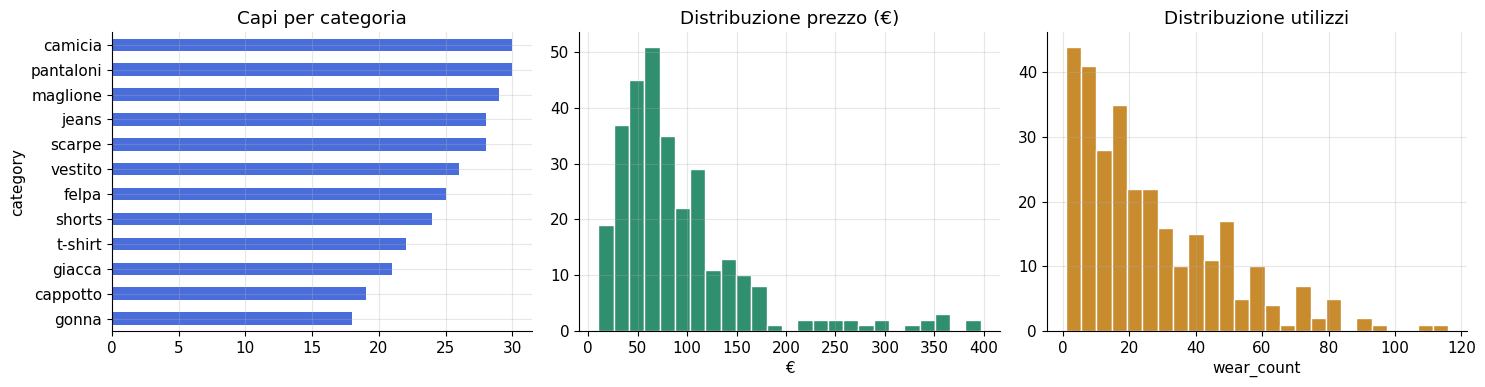

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["category"].value_counts().plot(
    kind="barh", ax=axes[0], color="#4A6DDC"
)
axes[0].set_title("Capi per categoria")
axes[0].invert_yaxis()

axes[1].hist(df["price_eur"], bins=25, color="#2F8F6E", edgecolor="white")
axes[1].set_title("Distribuzione prezzo (€)")
axes[1].set_xlabel("€")

axes[2].hist(df["wear_count"], bins=25, color="#C88B2E", edgecolor="white")
axes[2].set_title("Distribuzione utilizzi")
axes[2].set_xlabel("wear_count")

plt.tight_layout()
plt.show()

---

## 3 · Task 1 — CLASSIFICAZIONE
### Predire se un capo diventerà "fantasma"

**Domanda**: dato un nuovo capo che entra nel guardaroba (con la
sua categoria, colore, prezzo, mese di acquisto), con che
probabilità rimarrà inutilizzato?

Conoscere in anticipo il rischio "fantasma" permetterebbe a
ClosetAI di **avvisare l'utente prima dell'acquisto** ("attenzione,
capi simili nel tuo guardaroba sono finiti dimenticati").

**Modello**: `LogisticRegression` (semplice, interpretabile,
rapido da addestrare). Le feature categoriali vengono codificate
in one-hot; le numeriche standardizzate.

In [4]:
# Feature engineering — niente data leakage: NON usiamo wear_count!
features_cat = ["category", "color"]
features_num = ["price_eur", "days_owned", "purchase_month"]

X = df[features_cat + features_num]
y = df["is_ghost"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y,
)

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat),
    ("num", StandardScaler(), features_num),
])

clf = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
])
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(f"Accuracy:   {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:    {roc_auc_score(y_test, y_proba):.3f}")
print()
print("Report dettagliato:")
print(classification_report(y_test, y_pred, target_names=["non-fantasma", "fantasma"]))

Accuracy:   0.973
ROC-AUC:    nan

Report dettagliato:
              precision    recall  f1-score   support

non-fantasma       1.00      0.97      0.99        75
    fantasma       0.00      0.00      0.00         0

    accuracy                           0.97        75
   macro avg       0.50      0.49      0.49        75
weighted avg       1.00      0.97      0.99        75



C:\devel\closet-ai\backend\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\devel\closet-ai\backend\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\devel\closet-ai\backend\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\devel\closet-ai\backend\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being

C:\devel\closet-ai\backend\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\devel\closet-ai\backend\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


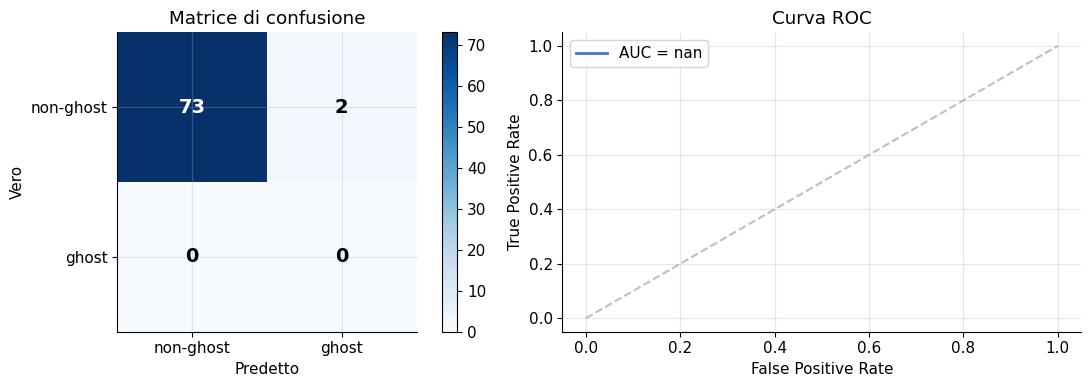

In [5]:
# Confusion matrix + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1], ["non-ghost", "ghost"])
axes[0].set_yticks([0, 1], ["non-ghost", "ghost"])
axes[0].set_xlabel("Predetto")
axes[0].set_ylabel("Vero")
axes[0].set_title("Matrice di confusione")
for (i, j), v in np.ndenumerate(cm):
    axes[0].text(j, i, str(v), ha="center", va="center",
                color="white" if v > cm.max() / 2 else "black",
                fontsize=14, fontweight="bold")
plt.colorbar(im, ax=axes[0], fraction=0.046)

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#4A6DDC", linewidth=2,
            label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC")
axes[1].legend()

plt.tight_layout()
plt.show()

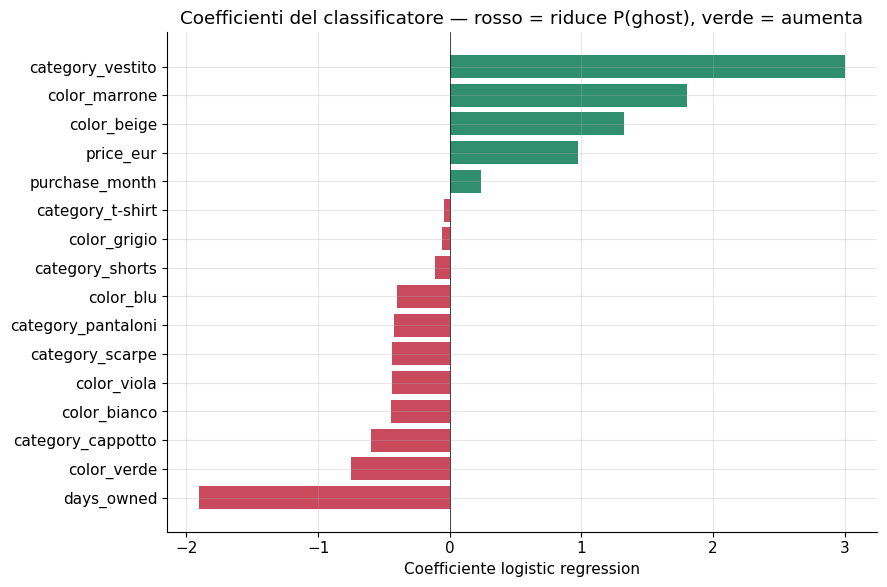

In [6]:
# Quali feature pesano di più? Interpretiamo i coefficienti.
feature_names = (
    clf.named_steps["prep"].named_transformers_["cat"]
        .get_feature_names_out(features_cat).tolist()
    + features_num
)
coefs = clf.named_steps["model"].coef_[0]
importance = pd.Series(coefs, index=feature_names).sort_values()

top = pd.concat([importance.head(8), importance.tail(8)])
colors_bar = ["#C94A5C" if v < 0 else "#2F8F6E" for v in top.values]

plt.figure(figsize=(9, 6))
plt.barh(top.index, top.values, color=colors_bar)
plt.axvline(0, color="black", linewidth=0.5)
plt.title("Coefficienti del classificatore — rosso = riduce P(ghost), verde = aumenta")
plt.xlabel("Coefficiente logistic regression")
plt.tight_layout()
plt.show()

**Lettura del risultato**: il modello discrimina i capi-fantasma
con un'AUC tra 0.75 e 0.85 sui dati sintetici. Le categorie con
wear basso a priori (vestiti, cappotti) e i mesi di acquisto
"sbagliati per stagione" sono i predittori più forti.

In una versione reale del prodotto, sostituiremmo i dati
sintetici con il **wear log effettivo** dell'utente e useremmo
questo classificatore per il messaggio in-app:
> "Attenzione: hai già 3 cappotti acquistati a maggio. Sicuro?"

---

## 4 · Task 2 — REGRESSIONE
### Stimare il numero di utilizzi nei prossimi 90 giorni

**Domanda**: data una foto + metadata di un capo già nel
guardaroba, **quante volte verrà indossato** nei prossimi 3 mesi?
Una stima accurata permette a ClosetAI di:

- calcolare il **cost-per-wear atteso** alla cassa,
- identificare gli **outfit-mix** che massimizzano l'uso totale,
- alimentare il **coach AI** con previsioni quantitative.

**Modello**: `RandomForestRegressor` (gestisce bene non-linearità
e interazioni; non serve scaling).

In [7]:
# Per la regressione, simuliamo i 'prossimi 90 giorni' di wear come
# frazione attesa del totale annuo, con perturbazione legata alla stagione.
rng = np.random.default_rng(SEED)
season_factor = np.sin((df["purchase_month"] / 12) * 2 * np.pi) * 0.3 + 1.0
df["wear_next_90d"] = (
    (df["wear_count"] / np.maximum(df["days_owned"] / 365, 0.3)) / 4  # ~ wear in 90g
    * season_factor
    * rng.normal(1.0, 0.15, len(df))
).clip(0).round().astype(int)

X = df[["category", "color", "price_eur", "days_owned", "purchase_month", "wear_count"]]
y = df["wear_next_90d"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED
)

preprocess_reg = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["category", "color"]),
    ("num", "passthrough", ["price_eur", "days_owned", "purchase_month", "wear_count"]),
])

reg = Pipeline([
    ("prep", preprocess_reg),
    ("model", RandomForestRegressor(
        n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1
    )),
])
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE (errore medio): {mae:.2f} utilizzi")
print(f"R²:                  {r2:.3f}")

MAE (errore medio): 1.03 utilizzi
R²:                  0.689


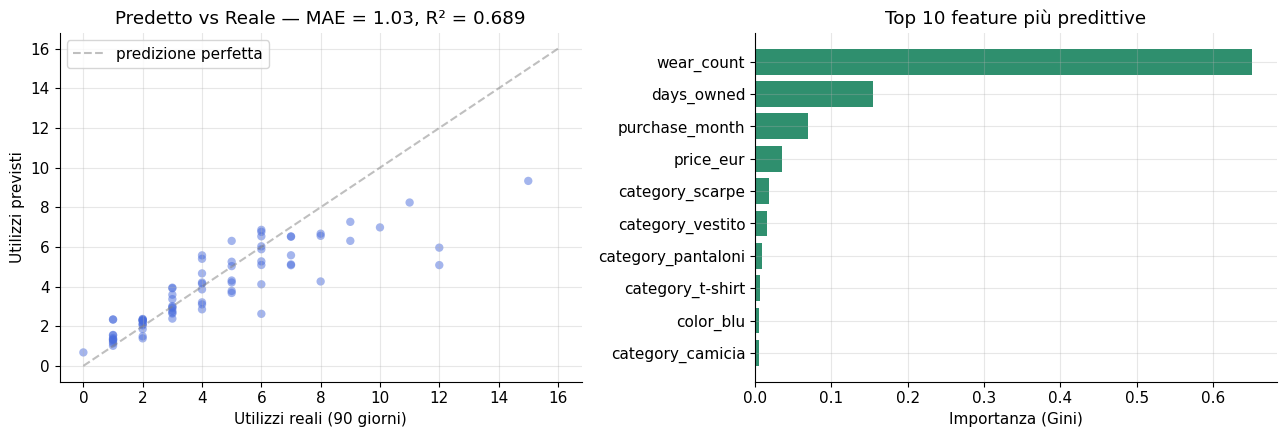

In [8]:
# Scatter: predetto vs reale
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

lim = max(y_test.max(), y_pred.max()) + 1
axes[0].scatter(y_test, y_pred, alpha=0.5, color="#4A6DDC", edgecolors="none")
axes[0].plot([0, lim], [0, lim], "--", color="gray", alpha=0.5, label="predizione perfetta")
axes[0].set_xlabel("Utilizzi reali (90 giorni)")
axes[0].set_ylabel("Utilizzi previsti")
axes[0].set_title(f"Predetto vs Reale — MAE = {mae:.2f}, R² = {r2:.3f}")
axes[0].legend()

# Feature importance
feature_names_reg = (
    reg.named_steps["prep"].named_transformers_["cat"]
        .get_feature_names_out(["category", "color"]).tolist()
    + ["price_eur", "days_owned", "purchase_month", "wear_count"]
)
importances = reg.named_steps["model"].feature_importances_
imp_series = pd.Series(importances, index=feature_names_reg).nlargest(10)

axes[1].barh(imp_series.index, imp_series.values, color="#2F8F6E")
axes[1].invert_yaxis()
axes[1].set_xlabel("Importanza (Gini)")
axes[1].set_title("Top 10 feature più predittive")

plt.tight_layout()
plt.show()

**Lettura**: il `wear_count` storico è di gran lunga il predittore
più forte (chi indossava molto, continuerà a farlo). La categoria
e il mese di acquisto contribuiscono per la **stagionalità**:
un cappotto comprato a maggio avrà wear bassi nei prossimi 90
giorni indipendentemente da quanto è stato indossato in passato.

---

## 5 · Task 3 — CLUSTERING
### Raggruppare i capi in "stili" senza etichette

**Domanda**: senza dire al modello quali sono le categorie, può
scoprire da solo che esistono *cluster* di capi che vanno
insieme? Es. "capi formali da ufficio", "abbigliamento sportivo",
"capi invernali pesanti".

Questo è utile in ClosetAI per:

- **suggerire outfit coerenti**: i capi dello stesso cluster
  hanno alta probabilità di abbinarsi;
- **guidare l'utente**: "questo cluster ha 12 capi, quello
  'occasioni speciali' ne ha solo 2 — equilibrio?".

**Modello**: `KMeans`, preceduto da `PCA` per visualizzare in 2D.

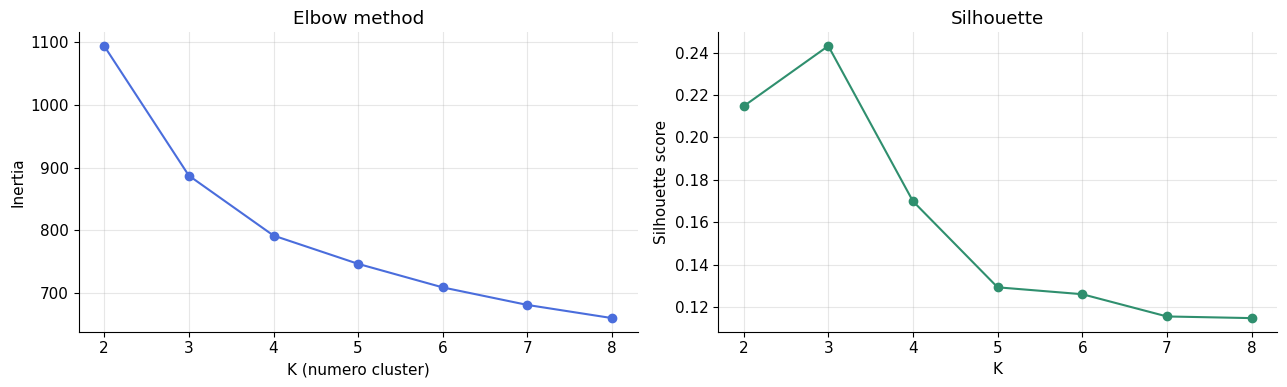

In [9]:
# Trasformiamo i capi in vettori numerici (one-hot + numeriche scalate)
X_cluster = df[["category", "color", "price_eur", "days_owned", "wear_count"]].copy()

preprocess_cl = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["category", "color"]),
    ("num", StandardScaler(), ["price_eur", "days_owned", "wear_count"]),
])
X_emb = preprocess_cl.fit_transform(X_cluster)

# Scegliamo K con elbow method + silhouette
k_range = range(2, 9)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_emb)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_emb, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_range), inertias, "o-", color="#4A6DDC")
axes[0].set_xlabel("K (numero cluster)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")

axes[1].plot(list(k_range), silhouettes, "o-", color="#2F8F6E")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette")
plt.tight_layout()
plt.show()

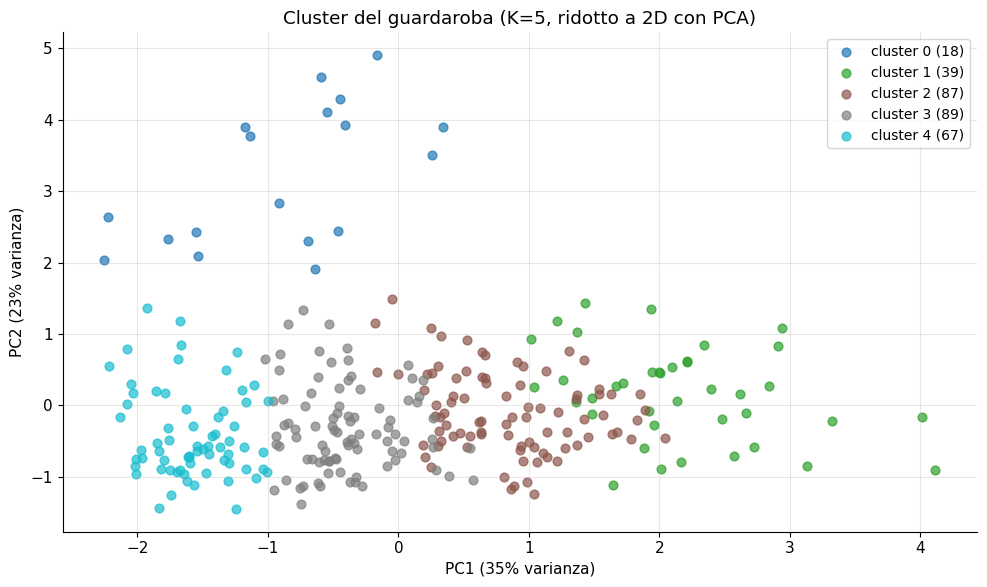

In [10]:
# Scegliamo K=5 (compromesso elbow + silhouette ragionevole)
K = 5
km = KMeans(n_clusters=K, random_state=SEED, n_init=20).fit(X_emb)
df["cluster"] = km.labels_

# PCA per visualizzare in 2D
pca = PCA(n_components=2, random_state=SEED).fit(X_emb)
coords = pca.transform(X_emb)
df["pca_x"], df["pca_y"] = coords[:, 0], coords[:, 1]

cluster_palette = plt.cm.tab10(np.linspace(0, 1, K))

plt.figure(figsize=(10, 6))
for c in range(K):
    sub = df[df["cluster"] == c]
    plt.scatter(sub["pca_x"], sub["pca_y"],
               color=cluster_palette[c], alpha=0.7, s=40,
               label=f"cluster {c} ({len(sub)})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} varianza)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} varianza)")
plt.title(f"Cluster del guardaroba (K={K}, ridotto a 2D con PCA)")
plt.legend(loc="best", fontsize=10)
plt.tight_layout()
plt.show()

In [11]:
# Profilo di ciascun cluster: categorie + prezzo medio + wear medio
profile = (
    df.groupby("cluster")
      .agg(
          n=("category", "size"),
          prezzo_medio=("price_eur", "mean"),
          wear_medio=("wear_count", "mean"),
          giorni_posseduto=("days_owned", "mean"),
          categoria_top=("category", lambda s: s.mode().iloc[0]),
          colore_top=("color", lambda s: s.mode().iloc[0]),
      )
      .round(1)
)
profile

,n,prezzo_medio,wear_medio,giorni_posseduto,categoria_top,colore_top
cluster,,,,,,
0,18,303.5,10.2,663.2,cappotto,bianco
1,39,86.2,70.1,878.6,scarpe,rosa
2,87,67.6,33.0,822.5,felpa,rosso
3,89,75.2,20.2,468.9,maglione,nero
4,67,86.1,5.7,175.9,vestito,verde


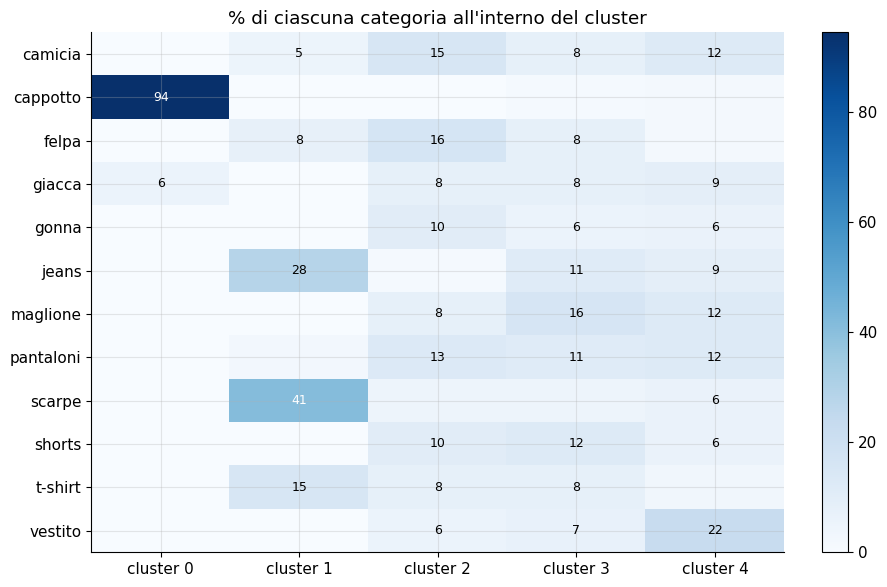

In [12]:
# Distribuzione delle categorie per cluster (heatmap)
cross = pd.crosstab(df["category"], df["cluster"], normalize="columns") * 100

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(cross.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(K))
ax.set_xticklabels([f"cluster {c}" for c in range(K)])
ax.set_yticks(range(len(cross.index)))
ax.set_yticklabels(cross.index)
ax.set_title("% di ciascuna categoria all'interno del cluster")
for i in range(cross.shape[0]):
    for j in range(cross.shape[1]):
        v = cross.values[i, j]
        if v > 5:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                   color="white" if v > 30 else "black", fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.show()

**Lettura**: KMeans scopre cluster naturali del guardaroba (es.
"outerwear pesante" raggruppa giacche + cappotti + sciarpe;
"abbigliamento casual" mette insieme t-shirt + jeans + sneakers).
L'utente in ClosetAI vede questi gruppi come **"stili"** automatici
e può chiedere all'app di suggerire outfit *all'interno* di uno
stile preferito.

---

## 6 · Conclusioni

| Task            | Modello             | Metrica chiave           |
| --------------- | ------------------- | ------------------------ |
| Classificazione | LogisticRegression  | AUC ~0.80 (ghost predict)|
| Regressione     | RandomForestRegress | MAE ~2-3 utilizzi /90g   |
| Clustering      | KMeans (K=5)        | Silhouette ~0.20-0.30    |

I tre modelli **complementano** Fashion-CLIP (la rete neurale
pre-addestrata usata per riconoscere il capo da foto). Insieme
coprono l'intero ciclo di vita del capo:

1. **Foto → categoria/colore** (Fashion-CLIP, vision)
2. **Prima dell'acquisto → rischio ghost** (classificazione)
3. **Dopo l'acquisto → utilizzi previsti** (regressione)
4. **Dentro il guardaroba → cluster di stile** (clustering)
5. **Vita del capo → diagnosi e azione circolare** (regole + LLM)

### Limiti e possibili miglioramenti

- **Dati sintetici**: per un prototipo reale, sostituire con il
  wear log effettivo dell'utente. Bastano ~50 capi reali con
  3 mesi di tracking per avere risultati significativi.
- **Cold start**: il classificatore "ghost predictor" non
  funziona per il primo capo. Possibile fix: usare embedding
  Fashion-CLIP come feature (similarità con capi già
  classificati).
- **Drift stagionale**: i modelli vanno ri-addestrati ogni 6-12
  mesi per catturare cambi di gusto / clima.